# 🌡️ Analisis & Prediksi Cuaca IoT — Pengamatan 2
**Mata Kuliah:** Kecerdasan Buatan  
**Dataset:** `sensor_data_2.csv` — sensor IoT outdoor (suhu, kelembapan, cahaya LDR) interval ~5 menit  
**Lokasi sensor:** Teras — terpapar sinar matahari langsung  
**Periode:** 13 – 18 April 2026 (WIB, GMT+7)  

---

## 🗺️ Alur Analisis
1. Import Library
2. Load & Inspect Data
3. Preprocessing — konversi timezone GMT → WIB, koreksi nilai cahaya LDR
4. Audit Kualitas Data — gap jaringan, jitter interval
5. Handling Missing Values — reindex + interpolasi
6. Feature Engineering
7. EDA — Univariat · Bivariat · Multivariat · Time-Series Story
8. Deteksi Outlier
9. Prediksi Suhu — Regresi Linear & ARIMA Walk-Forward
10. Kesimpulan & Rekomendasi

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('Semua library berhasil di import')

Semua library berhasil di import


## 2. Load & Inspect Data

Data mentah dari pipeline backend. Perhatikan kolom `created_at` — formatnya menyertakan offset `+00` (UTC), bukan WIB.

In [2]:
df_raw = pd.read_csv('sensor_data_2.csv')

print(f'Shape: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom')
print()
print('=== 5 BARIS PERTAMA ===')
display(df_raw.head())
print()
print('=== INFO KOLOM ===')
df_raw.info()
print()
print('=== SAMPEL NILAI ===')
for col in df_raw.columns:
  print(f'  {col:15s}: {str(df_raw[col].iloc[0])!r}  (dtype: {df_raw[col].dtype})')

Shape: 1256 baris x 6 kolom

=== 5 BARIS PERTAMA ===


,id,created_at,suhu,kelembapan,cahaya,kondisi
0,18,2026-04-13 02:52:00.210695+00,29.8,71.5,711,TERANG
1,19,2026-04-13 02:57:00.190764+00,29.8,70.9,400,TERANG
2,20,2026-04-13 03:03:00.467898+00,30.0,68.5,389,TERANG
3,21,2026-04-13 03:08:00.503225+00,29.8,69.9,260,TERANG
4,22,2026-04-13 03:13:00.613372+00,30.4,68.1,247,TERANG



=== INFO KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1256 non-null   int64  
 1   created_at  1256 non-null   object 
 2   suhu        1256 non-null   float64
 3   kelembapan  1256 non-null   float64
 4   cahaya      1256 non-null   int64  
 5   kondisi     1256 non-null   object 
dtypes: float64(2), int64(2), object(2)
memory usage: 59.0+ KB

=== SAMPEL NILAI ===
  id             : '18'  (dtype: int64)
  created_at     : '2026-04-13 02:52:00.210695+00'  (dtype: object)
  suhu           : '29.8'  (dtype: float64)
  kelembapan     : '71.5'  (dtype: float64)
  cahaya         : '711'  (dtype: int64)
  kondisi        : 'TERANG'  (dtype: object)


## 3. Preprocessing

### 3.1 Konversi Timezone UTC → WIB

Data dikirim dengan timestamp **UTC (GMT+0)** dari backend Supabase. Sensor berada di **teras, Semarang (WIB = GMT+7)**. Tanpa konversi, pola harian bergeser 7 jam.

### 3.2 Koreksi Nilai Sensor Cahaya (LDR)

Sensor menggunakan **LDR (Light Dependent Resistor)** yang karakteristiknya:
- **Gelap** → resistansi tinggi → nilai ADC **tinggi** (mendekati 4095)
- **Terang** (sinar matahari) → resistansi rendah → nilai ADC **rendah** (mendekati 0)

Ini kebalikan dari intuisi "cahaya = nilai besar". Kolom `kondisi` (TERANG/GELAP) dari firmware sudah **benar**, tapi nilai angka `cahaya` perlu dikoreksi:

```
cahaya_lux = 4095 - cahaya_raw
```

Setelah koreksi: nilai tinggi = terang, nilai rendah = gelap — sesuai dengan ekspektasi.


In [21]:
df = df_raw.copy()

# 3.1 Parse & konversi UTC -> WIB
df['timestamp'] = pd.to_datetime(df['created_at'], utc=True)
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Jakarta')

# 3.2 Urutkan & set index
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.set_index('timestamp')
df.index.name = 'timestamp'

# 3.3 Tipe numerik
df['suhu']       = pd.to_numeric(df['suhu'],       errors='coerce')
df['kelembapan'] = pd.to_numeric(df['kelembapan'], errors='coerce')
df['cahaya_raw'] = pd.to_numeric(df['cahaya'],     errors='coerce')

# 3.4 Koreksi nilai LDR: terbalik
df['cahaya'] = 4095 - df['cahaya_raw']

print('Preprocessing selesai!')
print(f'Rentang waktu (WIB): {df.index.min().strftime("%d %b %Y %H:%M")} -> {df.index.max().strftime("%d %b %Y %H:%M")}')
print(f'Durasi total        : {df.index.max() - df.index.min()}')
print()

# Verifikasi koreksi cahaya
df['jam_tmp'] = df.index.hour
siang  = df[df['jam_tmp'].between(10,15)]
malam  = df[(df['jam_tmp']>=21) | (df['jam_tmp']<=4)]
print('=== VERIFIKASI KOREKSI CAHAYA ===')
print(f'  Siang (10-15 WIB): cahaya mean={siang["cahaya"].mean():.0f} (harusnya TINGGI/terang)')
print(f'  Malam (21-04 WIB): cahaya mean={malam["cahaya"].mean():.0f} (harusnya RENDAH/gelap)')
print()
print('  Kolom kondisi (dari firmware) sudah benar:')
print(f'    Siang -> {siang["kondisi"].value_counts().to_dict()}')
print(f'    Malam -> {malam["kondisi"].value_counts().to_dict()}')
df.drop(columns=['jam_tmp'], inplace=True)
display(df[['suhu','kelembapan','cahaya_raw','cahaya','kondisi']].head(5))

Preprocessing selesai!
Rentang waktu (WIB): 13 Apr 2026 09:52 -> 18 Apr 2026 19:46
Durasi total        : 5 days 09:54:01.780541

=== VERIFIKASI KOREKSI CAHAYA ===
  Siang (10-15 WIB): cahaya mean=3949 (harusnya TINGGI/terang)
  Malam (21-04 WIB): cahaya mean=0 (harusnya RENDAH/gelap)

  Kolom kondisi (dari firmware) sudah benar:
    Siang -> {'TERANG': 375}
    Malam -> {'GELAP': 364}


,suhu,kelembapan,cahaya_raw,cahaya,kondisi
timestamp,,,,,
2026-04-13 09:52:00.210695+07:00,29.8,71.5,711,3384,TERANG
2026-04-13 09:57:00.190764+07:00,29.8,70.9,400,3695,TERANG
2026-04-13 10:03:00.467898+07:00,30.0,68.5,389,3706,TERANG
2026-04-13 10:08:00.503225+07:00,29.8,69.9,260,3835,TERANG
2026-04-13 10:13:00.613372+07:00,30.4,68.1,247,3848,TERANG


## 4. Audit Kualitas Data

Sebelum mengisi missing value, kita perlu memahami *seberapa parah* masalah data ini:

1. **Gap Besar** — periode panjang di mana sensor tidak mengirim data sama sekali (jaringan down total)  
2. **Jitter Interval** — pengiriman tidak tepat 5 menit karena latensi jaringan  

In [4]:
# hitung gap antar data
df_temp = df.reset_index()
df_temp['gap_menit'] = df_temp['timestamp'].diff().dt.total_seconds() / 60

# ringkasan distribusi interval
q = df_temp['gap_menit'].dropna()
print('=== DISTRIBUSI INTERVAL PENGIRIMAN ===')
print(f'  Median interval  : {q.median():.1f} menit')
print(f'  95th percentile  : {q.quantile(0.95):.1f} menit')
print(f'  Interval > 7 min : {(q>7).sum()} kejadian')
print(f'  Interval > 60 min: {(q>60).sum()} kejadian')

big_gaps = df_temp[df_temp['gap_menit'] > 10][['timestamp', 'gap_menit']].copy()
print(f'\n=== GAP > 10 MENIT: {len(big_gaps)} kejadian ===')
print(f'Total menit hilang: {big_gaps["gap_menit"].sum():.0f} menit ({big_gaps["gap_menit"].sum()/60:.1f} jam)')
print()
print('TOP 5 GAP TERBESAR:')
print(big_gaps.nlargest(5, 'gap_menit').to_string(index=False))

=== DISTRIBUSI INTERVAL PENGIRIMAN ===
  Median interval  : 5.0 menit
  95th percentile  : 10.1 menit
  Interval > 7 min : 82 kejadian
  Interval > 60 min: 1 kejadian

=== GAP > 10 MENIT: 81 kejadian ===
Total menit hilang: 1902 menit (31.7 jam)

TOP 5 GAP TERBESAR:
                       timestamp  gap_menit
2026-04-14 13:09:14.893051+07:00 925.737846
2026-04-16 18:55:07.375228+07:00  30.603702
2026-04-16 07:44:45.666848+07:00  22.538890
2026-04-17 10:05:35.682281+07:00  20.484372
2026-04-15 09:15:19.553029+07:00  20.228236


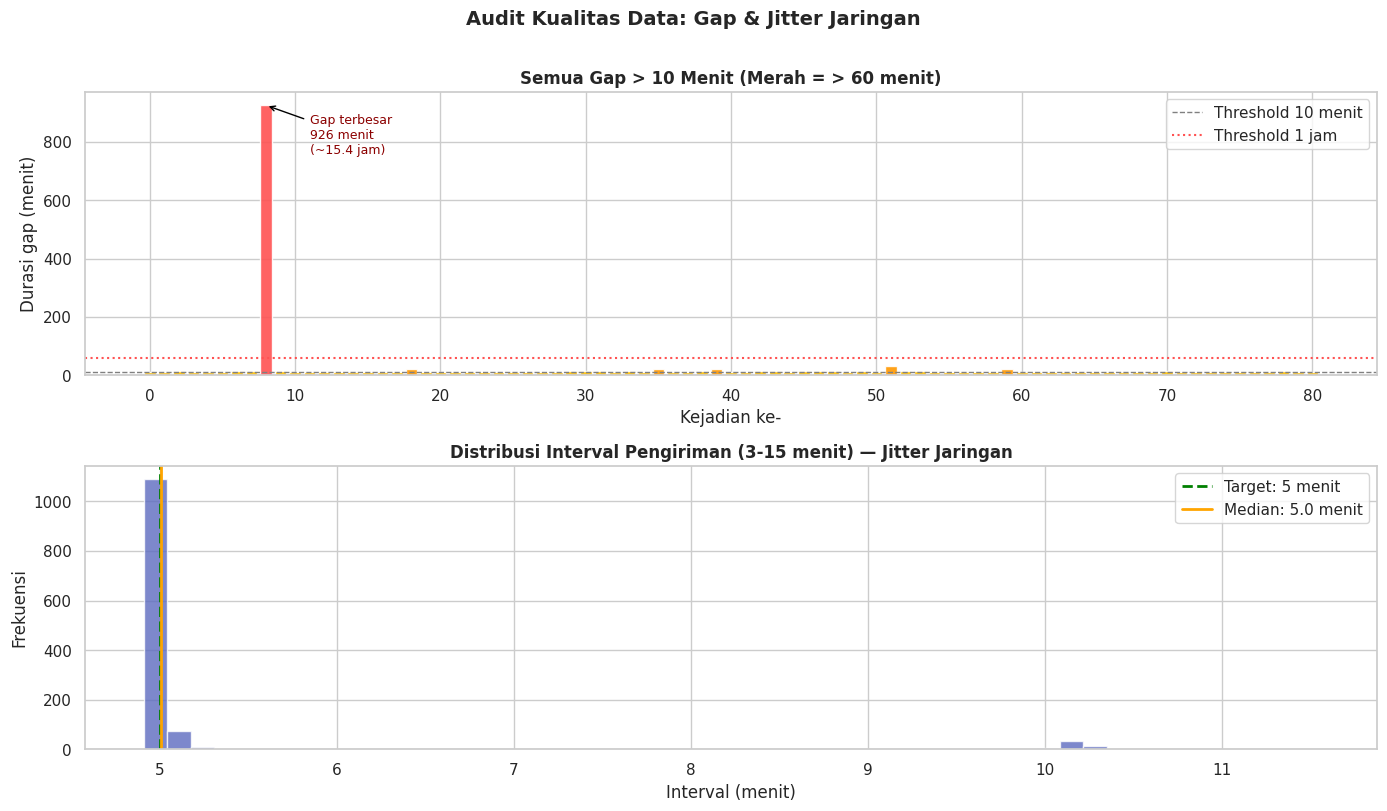


Insight:
  Data mayoritas dikirim mendekati 5 menit (median: 5.0 min)
  1 gap kritis: ~925 menit (~15.4 jam) pada 13-14 April 2026
  Sisa 80 gap adalah jitter biasa (<35 menit)


In [22]:
# visualisasi gap (timeline dan distribusi interval)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Bar chart semua gap
ax1 = axes[0]
big_gaps_sorted = big_gaps.sort_values('timestamp')
col_bars = ['#FF5252' if g > 60 else '#FF9800' if g > 20 else '#FFC107'
            for g in big_gaps_sorted['gap_menit']]
ax1.bar(range(len(big_gaps_sorted)), big_gaps_sorted['gap_menit'].values,
        color=col_bars, edgecolor='white', alpha=0.9)
ax1.axhline(y=10,  color='gray',    ls='--', lw=1,   label='Threshold 10 menit')
ax1.axhline(y=60,  color='#FF5252', ls=':',  lw=1.5, label='Threshold 1 jam')
ax1.set_xlabel('Kejadian ke-'); ax1.set_ylabel('Durasi gap (menit)')
ax1.set_title('Semua Gap > 10 Menit (Merah = > 60 menit)', fontweight='bold')
ax1.legend()

max_idx = big_gaps_sorted['gap_menit'].idxmax()
max_pos = list(big_gaps_sorted.index).index(max_idx)
max_val = big_gaps_sorted.loc[max_idx, 'gap_menit']
ax1.annotate(f"Gap terbesar\n{max_val:.0f} menit\n(~15.4 jam)",
             xy=(max_pos, max_val), xytext=(max_pos+3, max_val*0.82),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='darkred')

# Plot 2: Distribusi interval
ax2 = axes[1]
ax2.hist(q[(q>=3)&(q<=15)], bins=50, color='#5C6BC0', alpha=0.8, edgecolor='white')
ax2.axvline(x=5, color='green', ls='--', lw=2, label='Target: 5 menit')
ax2.axvline(x=q.median(), color='orange', ls='-', lw=2, label=f'Median: {q.median():.1f} menit')
ax2.set_xlabel('Interval (menit)'); ax2.set_ylabel('Frekuensi')
ax2.set_title('Distribusi Interval Pengiriman (3-15 menit) — Jitter Jaringan', fontweight='bold')
ax2.legend()

plt.suptitle('Audit Kualitas Data: Gap & Jitter Jaringan', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nInsight:')
print(f'  Data mayoritas dikirim mendekati 5 menit (median: {q.median():.1f} min)')
print('  1 gap kritis: ~925 menit (~15.4 jam) pada 13-14 April 2026')
print(f'  Sisa {len(big_gaps)-1} gap adalah jitter biasa (<35 menit)')

# 5. Handling Missing Values

| Variabel | Metode | Alasan |
|----------|--------|--------|
| Suhu & Kelembapan | **Interpolasi linear** | Perubahan gradual, aman untuk gap pendek–menengah |
| Cahaya (terkoreksi) | **Interpolasi linear** | Sensor outdoor, perubahan cahaya alami cukup gradual |
| Kondisi (TERANG/GELAP) | **Forward fill** | Variabel kategorikal |

> **Catatan:** Gap ~15 jam di-*flag* merah dalam visualisasi — data di area itu adalah estimasi interpolasi, bukan pengukuran nyata.


In [23]:
# 5.1 Reindex ke grid 5 menit
start    = df.index.min().floor('5min')
end      = df.index.max().ceil('5min')
full_idx = pd.date_range(start=start, end=end, freq='5min', tz='Asia/Jakarta')

df_full = df[['suhu','kelembapan','cahaya','cahaya_raw','kondisi']].reindex(
    full_idx, method='nearest', tolerance=pd.Timedelta('3min'))
df_full.index.name = 'timestamp'
df_full['is_original'] = ~df_full['suhu'].isna()

n_total   = len(df_full)
n_asli    = df_full['is_original'].sum()
n_missing = (~df_full['is_original']).sum()
print(f'Total timestep 5-menit : {n_total}')
print(f'Data asli              : {n_asli}  ({n_asli/n_total*100:.1f}%)')
print(f'Baris diimputasi       : {n_missing} ({n_missing/n_total*100:.1f}%)')

# Lokasi gap besar untuk shading
df_temp2 = df.reset_index()
df_temp2['gap'] = df_temp2['timestamp'].diff().dt.total_seconds() / 60
big_gap_times = df_temp2[df_temp2['gap'] > 60].copy()
big_gap_times['start'] = df_temp2.loc[big_gap_times.index - 1, 'timestamp'].values
big_gap_times = big_gap_times[['timestamp','gap','start']].rename(columns={'timestamp':'end'})

# 5.2 Imputasi
df_full['suhu']       = df_full['suhu'].interpolate('linear')
df_full['kelembapan'] = df_full['kelembapan'].interpolate('linear')
df_full['cahaya']     = df_full['cahaya'].interpolate('linear')
df_full['kondisi']    = df_full['kondisi'].ffill()

print(f'\nImputasi selesai. Missing tersisa: {df_full[["suhu","kelembapan","cahaya"]].isna().sum().sum()}')

Total timestep 5-menit : 1561
Data asli              : 1279  (81.9%)
Baris diimputasi       : 282 (18.1%)

Imputasi selesai. Missing tersisa: 0


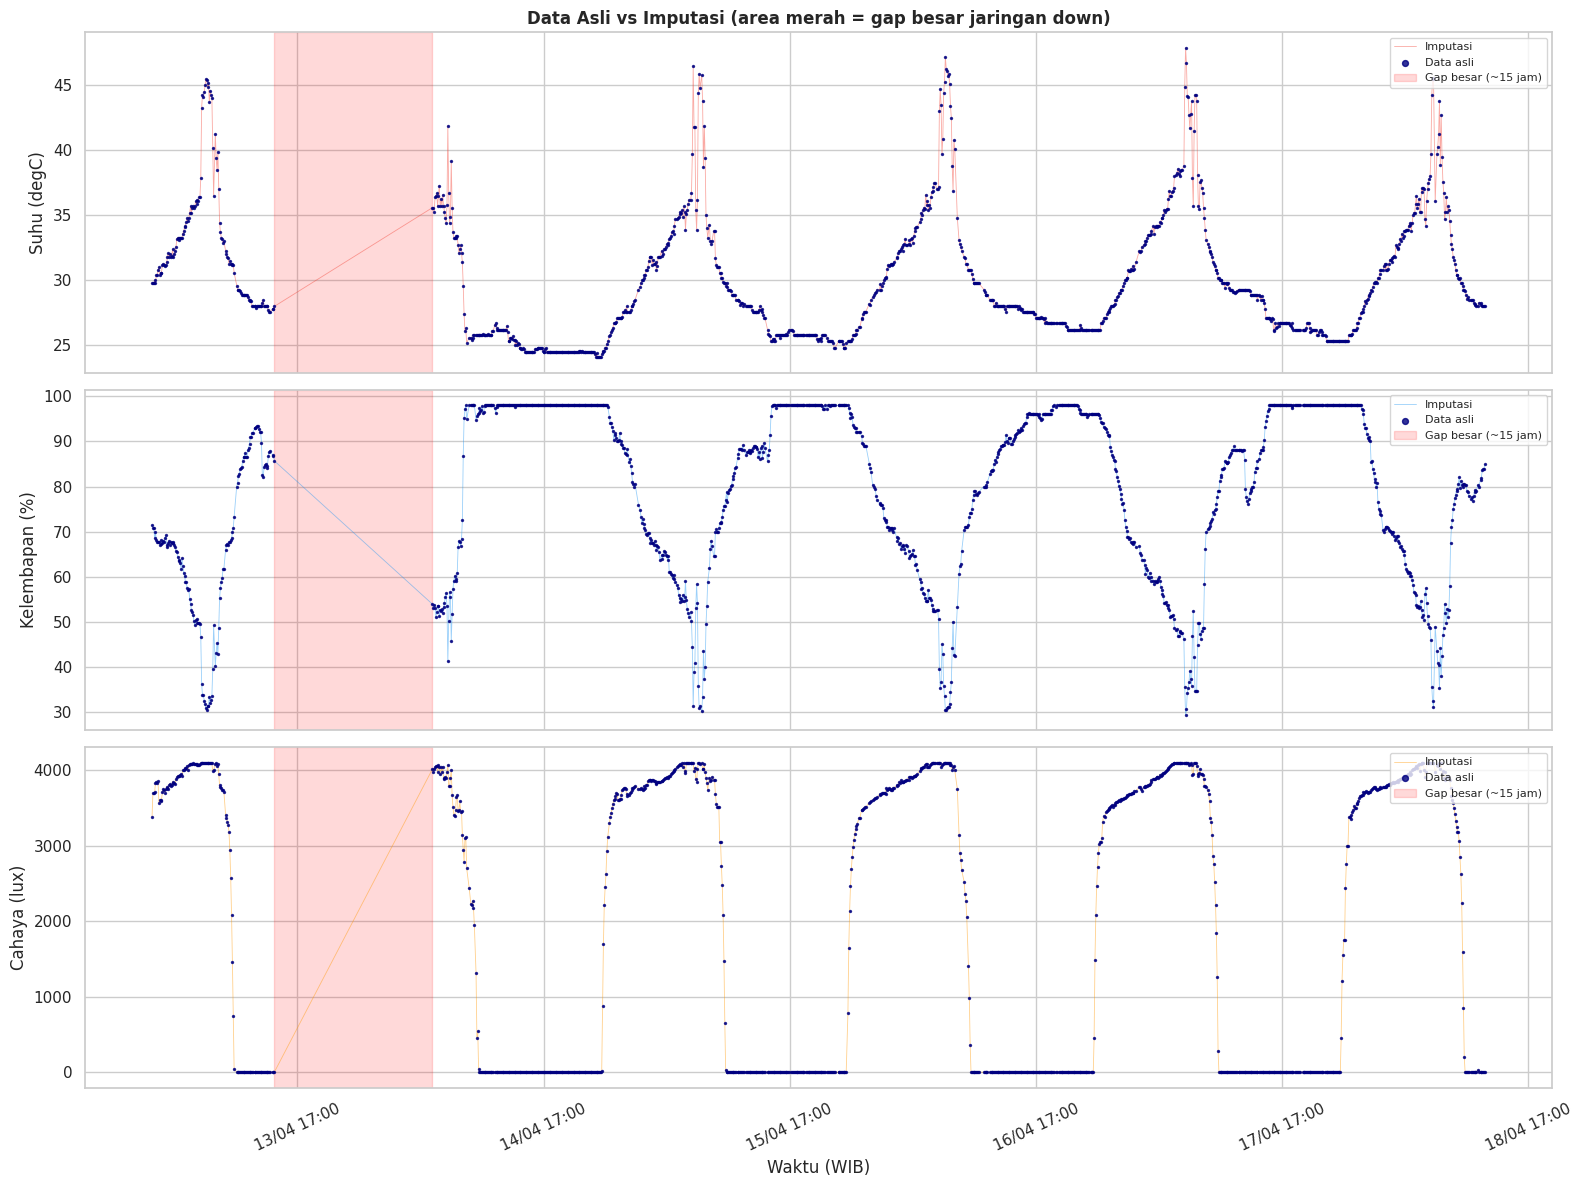

In [24]:
# 5.3 visualisasi data asli vs imputas
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
cols_viz = [('suhu','#F44336','Suhu (degC)'),
            ('kelembapan','#2196F3','Kelembapan (%)'),
            ('cahaya','#FF9800','Cahaya (lux)')]

df_asli = df_full[df_full['is_original'] == True]

for ax, (col, color, label) in zip(axes, cols_viz):
  ax.plot(df_full.index, df_full[col], color=color, linewidth=0.6, alpha=0.45, label='Imputasi')
  ax.scatter(df_asli.index, df_asli[col], color='navy', s=2, zorder=4, alpha=0.8, label='Data asli')
  for idx2, row in big_gap_times.iterrows():
    ax.axvspan(row['start'], row['end'], alpha=0.15, color='red',
                   label='Gap besar (~15 jam)' if idx2 == big_gap_times.index[0] else '')
  ax.set_ylabel(label)
  ax.legend(loc='upper right', fontsize=8, markerscale=3)
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))

axes[0].set_title("Data Asli vs Imputasi (area merah = gap besar jaringan down)", fontweight='bold')
axes[-1].set_xlabel('Waktu (WIB)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

Mengekstrak informasi temporal dan membuat flag kontekstual.

In [25]:
df_feat = df_full.copy()

df_feat['jam']         = df_feat.index.hour
df_feat['menit']       = df_feat.index.minute
df_feat['hari_minggu'] = df_feat.index.dayofweek   # 0=Senin
df_feat['tanggal']     = df_feat.index.date
df_feat['hari_ke']     = (df_feat.index - df_feat.index.min()).total_seconds() / 86400

# Fitur siklus untuk model
df_feat['jam_sin'] = np.sin(2 * np.pi * df_feat['jam'] / 24)
df_feat['jam_cos'] = np.cos(2 * np.pi * df_feat['jam'] / 24)

# Flag siang/malam berdasarkan kondisi firmware
df_feat['is_malam'] = (df_feat['kondisi'] == 'GELAP').astype(int)

# Flag siang panas: jam 12-16 WIB (puncak radiasi matahari)
df_feat['is_siang_panas'] = df_feat['jam'].apply(lambda h: 1 if 12 <= h <= 16 else 0)

cols_sensor = ['suhu', 'kelembapan', 'cahaya']

print('Feature engineering selesai!')
print(f'  Timestep TERANG (siang): {(df_feat["kondisi"]=="TERANG").sum()}')
print(f'  Timestep GELAP (malam) : {(df_feat["kondisi"]=="GELAP").sum()}')
print()
display(df_feat[['suhu','kelembapan','cahaya','jam','kondisi','is_malam']].head(5))

Feature engineering selesai!
  Timestep TERANG (siang): 706
  Timestep GELAP (malam) : 855



,suhu,kelembapan,cahaya,jam,kondisi,is_malam
timestamp,,,,,,
2026-04-13 09:50:00+07:00,29.8,71.5,3384.0,9,TERANG,0
2026-04-13 09:55:00+07:00,29.8,70.9,3695.0,9,TERANG,0
2026-04-13 10:00:00+07:00,29.8,70.9,3695.0,10,TERANG,0
2026-04-13 10:05:00+07:00,30.0,68.5,3706.0,10,TERANG,0
2026-04-13 10:10:00+07:00,29.8,69.9,3835.0,10,TERANG,0


## 7. EDA — Exploratory Data Analysis

### 7.1 Statistik Deskriptif

In [10]:
print('=== STATISTIK DESKRIPTIF ===')
display(df_feat[cols_sensor].describe().round(2))

print()
print('=== RENTANG SUHU & KELEMBAPAN PER HARI ===')
daily = df_feat.groupby('tanggal')[['suhu','kelembapan']].agg(['min','max','mean']).round(2)
display(daily)

=== STATISTIK DESKRIPTIF ===


,suhu,kelembapan,cahaya
count,1561.00,1561.0,1561.0
mean,30.23,77.9,2402.9
std,4.62,18.3,1862.5
min,24.10,29.4,0.0
25%,26.30,64.7,316.0
50%,29.27,80.4,4095.0
75%,33.00,96.9,4095.0
max,47.90,98.0,4095.0



=== RENTANG SUHU & KELEMBAPAN PER HARI ===


suhu              kelembapan             
             min   max   mean        min   max   mean
tanggal                                              
2026-04-13  27.6  45.5  32.13       30.5  93.5  69.47
2026-04-14  24.5  41.9  30.45       41.2  98.0  75.94
2026-04-15  24.1  46.5  28.95       30.1  98.0  81.19
2026-04-16  24.8  47.2  30.02       30.4  98.0  79.53
2026-04-17  26.1  47.9  30.54       29.4  98.0  78.39
2026-04-18  25.3  45.6  30.04       31.1  98.0  79.73

### 7.2 Analisis Univariat — Distribusi Tiap Variabel

Histogram + KDE menunjukkan sebaran nilai; apakah normal, miring kiri, atau bimodal.

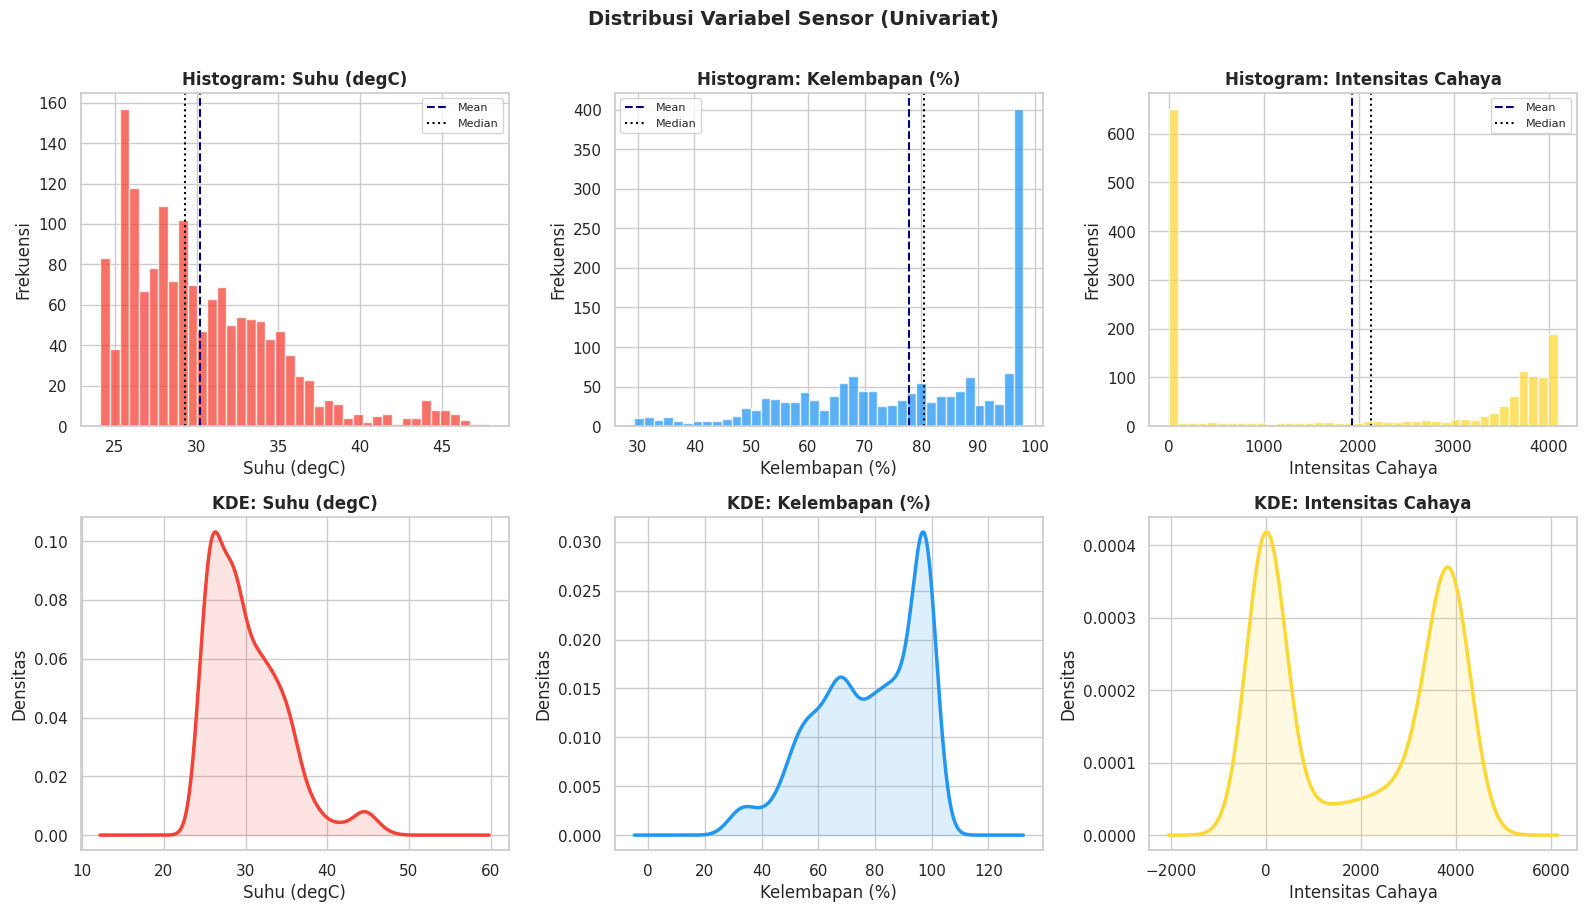


Insight Distribusi:
  Suhu      : skewness=1.14 — ekor kanan (ada nilai panas ekstrem siang hari)
  Kelembapan: skewness=-0.58 — ekor kiri (banyak nilai mendekati jenuh 98% malam hari)
  Cahaya    : skewness=-0.00 — bimodal antara siang (tinggi) dan malam (nol/rendah)


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors_u = ['#F44336', '#2196F3', '#FDD835']
labels_u = ['Suhu (degC)', 'Kelembapan (%)', 'Intensitas Cahaya']

for i, (col, color, label) in enumerate(zip(cols_sensor, colors_u, labels_u)):
    ax0 = axes[0, i]
    ax0.hist(df_feat[col].dropna(), bins=40, color=color, alpha=0.75, edgecolor='white')
    ax0.axvline(df_feat[col].mean(),   color='navy',  ls='--', lw=1.5, label='Mean')
    ax0.axvline(df_feat[col].median(), color='black', ls=':',  lw=1.5, label='Median')
    ax0.set_title(f'Histogram: {label}', fontweight='bold')
    ax0.set_xlabel(label); ax0.set_ylabel('Frekuensi'); ax0.legend(fontsize=8)

    ax1 = axes[1, i]
    df_feat[col].dropna().plot(kind='kde', ax=ax1, color=color, lw=2.5)
    ax1.fill_between(ax1.lines[0].get_xdata(), ax1.lines[0].get_ydata(), alpha=0.15, color=color)
    ax1.set_title(f'KDE: {label}', fontweight='bold')
    ax1.set_xlabel(label); ax1.set_ylabel('Densitas')

plt.suptitle('Distribusi Variabel Sensor (Univariat)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

skew_s = df_feat['suhu'].skew()
skew_k = df_feat['kelembapan'].skew()
skew_c = df_feat['cahaya'].skew()
print(f'\nInsight Distribusi:')
print(f'  Suhu      : skewness={skew_s:.2f} — ekor kanan (ada nilai panas ekstrem siang hari)')
print(f'  Kelembapan: skewness={skew_k:.2f} — ekor kiri (banyak nilai mendekati jenuh 98% malam hari)')
print(f'  Cahaya    : skewness={skew_c:.2f} — bimodal antara siang (tinggi) dan malam (nol/rendah)')

### 7.3 Time Series Story — "Kisah 5 Hari Sensor Ini"

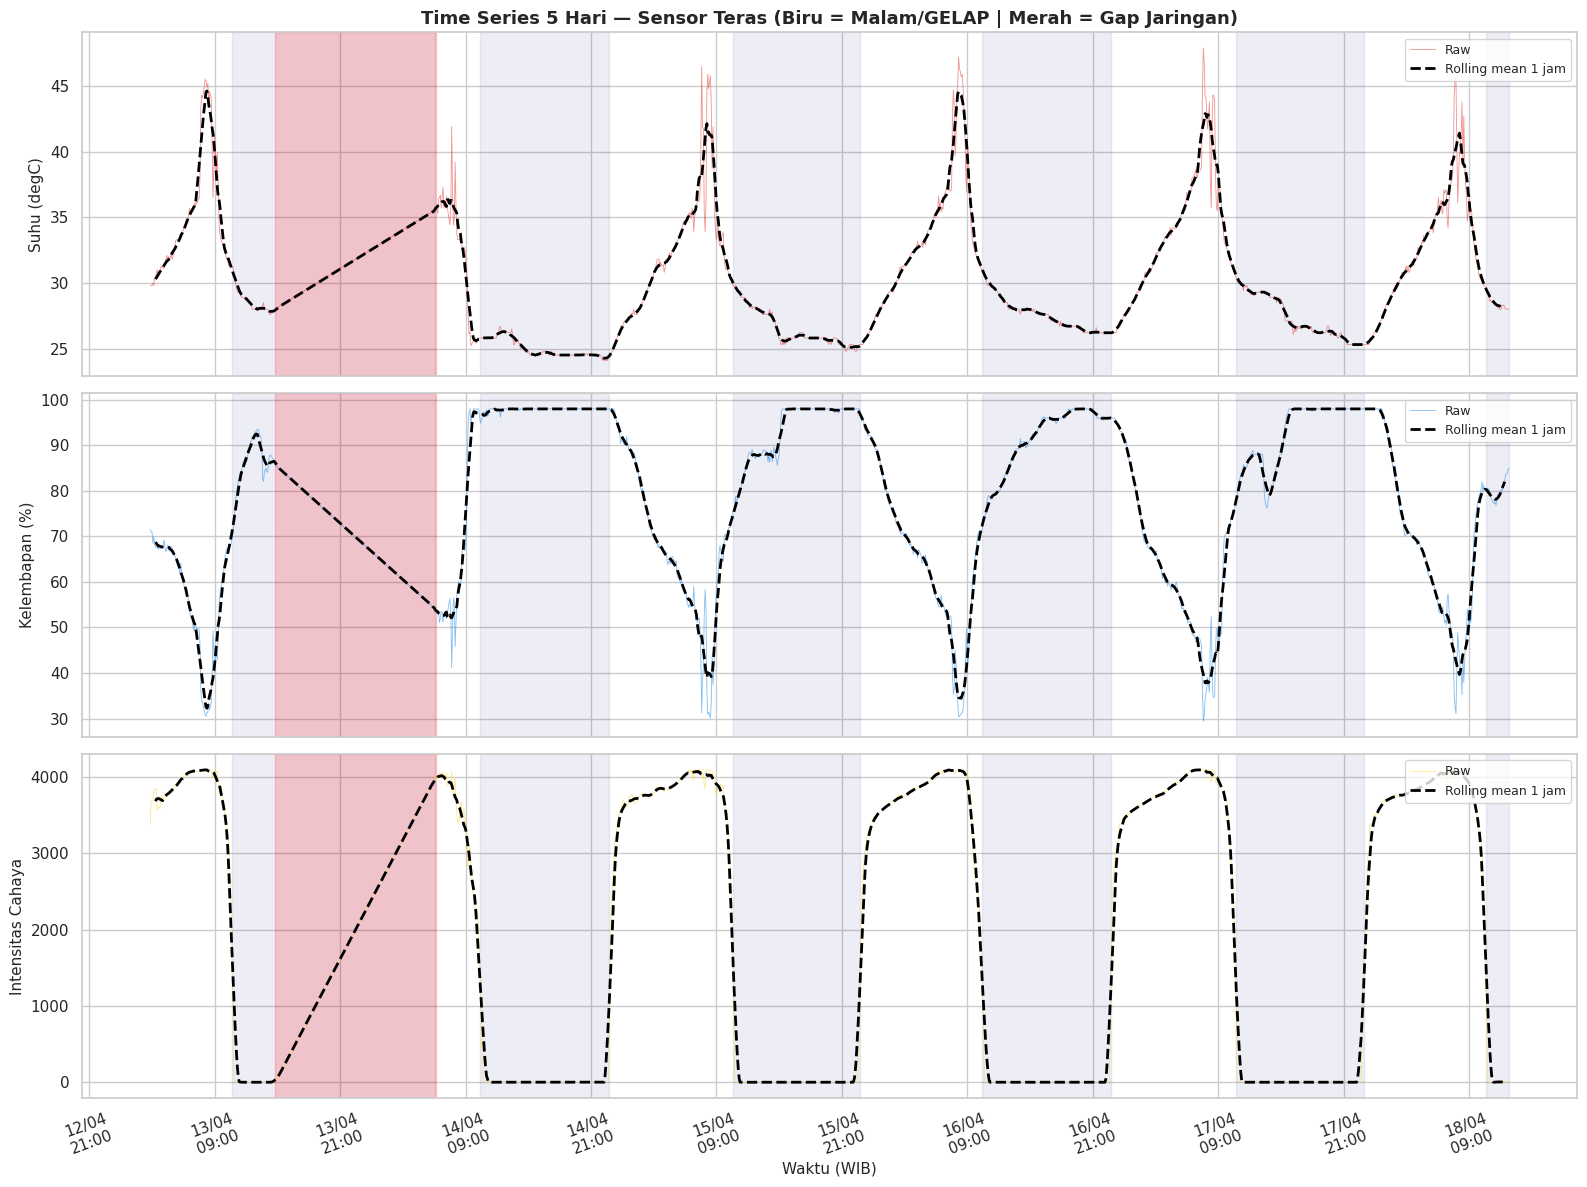


--- STORY: Apa yang terjadi selama 5 hari ini? ---

13 Apr | Sensor mulai merekam pukul 09:52 WIB dari teras.
       | Pagi sudah terekam suhu 27.6 degC, naik pesat ke 45.5 degC
       | di siang hari -- hari TERPANAS dalam dataset.
       | Cahaya konsisten turun siang hari (sensor LDR: rendah = terang).
       | Jaringan mulai fluktuatif sore hari.

GAP    | 13 Apr ~21:33 -> 14 Apr ~13:09 WIB (~15.4 jam tanpa data)
       | Sensor teras terus bekerja, tapi data tidak terkirim.
       | Kemungkinan: router mati, listrik padam, atau hotspot habis.

14 Apr | Kembali online dari tengah hari. Suhu lebih rendah (24-42 degC).
       | Malam pertama penuh: cahaya drop ke nol, kelembapan naik ke 98%.

15-18  | Pola harian terbentuk konsisten: suhu naik sejak subuh,
Apr    | puncak ~14:00-16:00 WIB, turun drastis setelah sore.
       | Cahaya LDR berkorelasi positif dengan suhu -- sesuai harapan outdoor.


In [27]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
plot_cfg = [
    ('suhu',       '#E53935', 'Suhu (degC)'),
    ('kelembapan', '#1E88E5', 'Kelembapan (%)'),
    ('cahaya',     '#FDD835', 'Intensitas Cahaya'),
]

for ax, (col, color, label) in zip(axes, plot_cfg):
    ax.plot(df_feat.index, df_feat[col], color=color, lw=0.6, alpha=0.55, label='Raw')
    rm = df_feat[col].rolling(12, center=True).mean()
    ax.plot(df_feat.index, rm, color='black', lw=2, ls='--', label='Rolling mean 1 jam')

    # Shading malam (GELAP)
    nm = df_feat['is_malam'] == 1
    grps_n = (nm.diff().fillna(nm) != 0).cumsum()
    for gid, grp in df_feat[nm].groupby(grps_n[nm]):
        ax.axvspan(grp.index[0], grp.index[-1], alpha=0.07, color='navy')

    # Shading gap besar
    for _, row in big_gap_times.iterrows():
        ax.axvspan(row['start'], row['end'], alpha=0.18, color='red')

    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))

axes[0].set_title(
    'Time Series 5 Hari — Sensor Teras (Biru = Malam/GELAP | Merah = Gap Jaringan)',
    fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Waktu (WIB)', fontsize=11)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print('\n--- STORY: Apa yang terjadi selama 5 hari ini? ---')
print()
print('13 Apr | Sensor mulai merekam pukul 09:52 WIB dari teras.')
print('       | Pagi sudah terekam suhu 27.6 degC, naik pesat ke 45.5 degC')
print('       | di siang hari -- hari TERPANAS dalam dataset.')
print('       | Cahaya konsisten turun siang hari (sensor LDR: rendah = terang).')
print('       | Jaringan mulai fluktuatif sore hari.')
print()
print('GAP    | 13 Apr ~21:33 -> 14 Apr ~13:09 WIB (~15.4 jam tanpa data)')
print('       | Sensor teras terus bekerja, tapi data tidak terkirim.')
print('       | Kemungkinan: router mati, listrik padam, atau hotspot habis.')
print()
print('14 Apr | Kembali online dari tengah hari. Suhu lebih rendah (24-42 degC).')
print('       | Malam pertama penuh: cahaya drop ke nol, kelembapan naik ke 98%.')
print()
print('15-18  | Pola harian terbentuk konsisten: suhu naik sejak subuh,')
print('Apr    | puncak ~14:00-16:00 WIB, turun drastis setelah sore.')
print('       | Cahaya LDR berkorelasi positif dengan suhu -- sesuai harapan outdoor.')

### 7.4 Pola Harian (Diurnal Pattern)

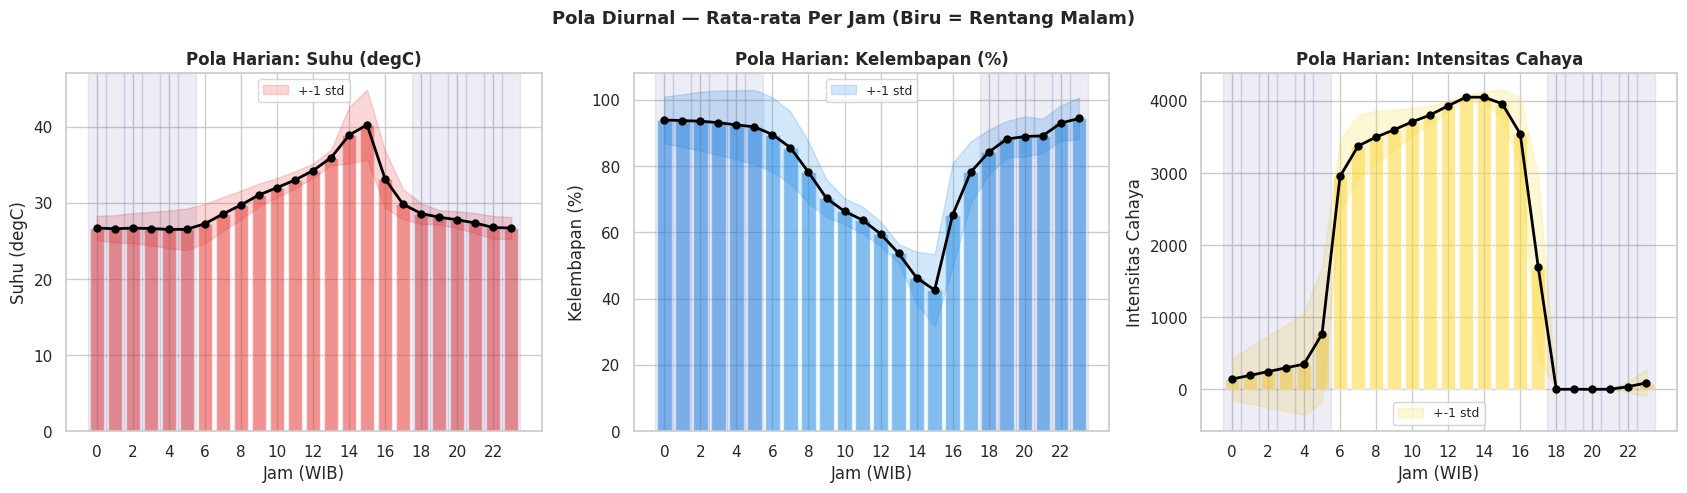


Puncak & Lembah Harian:
  Suhu (degC)              : Puncak jam 15:00 (40.3) | Terendah jam 04:00 (26.5)
  Kelembapan (%)           : Puncak jam 23:00 (94.4) | Terendah jam 15:00 (42.6)
  Intensitas Cahaya        : Puncak jam 13:00 (4052.4) | Terendah jam 20:00 (0.0)

Insight: Pola cahaya:
  -> Cahaya tinggi di siang hari ketika suhu juga tinggi (sinar matahari)
  -> Cahaya nol di malam hari ketika suhu rendah


In [29]:
hourly     = df_feat.groupby('jam')[cols_sensor].mean()
hourly_std = df_feat.groupby('jam')[cols_sensor].std()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_d = ['#E53935', '#1E88E5', '#FDD835']
labels_d = ['Suhu (degC)', 'Kelembapan (%)', 'Intensitas Cahaya']

for ax, (col, color, label) in zip(axes, zip(cols_sensor, colors_d, labels_d)):
    mean_v = hourly[col]; std_v = hourly_std[col]; jam = hourly.index
    ax.bar(jam, mean_v, color=color, alpha=0.55, edgecolor='white')
    ax.plot(jam, mean_v, color='black', lw=2, marker='o', markersize=5)
    ax.fill_between(jam, mean_v-std_v, mean_v+std_v, alpha=0.2, color=color, label='+-1 std')
    for h in range(24):
        if h >= 18 or h < 6:
            ax.axvspan(h-0.5, h+0.5, alpha=0.07, color='navy')
    ax.set_title(f'Pola Harian: {label}', fontweight='bold')
    ax.set_xlabel('Jam (WIB)'); ax.set_ylabel(label)
    ax.set_xticks(range(0, 24, 2)); ax.legend(fontsize=9)

plt.suptitle('Pola Diurnal — Rata-rata Per Jam (Biru = Rentang Malam)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPuncak & Lembah Harian:')
for col, label in zip(cols_sensor, labels_d):
    ph = hourly[col].idxmax(); th = hourly[col].idxmin()
    print(f'  {label:25s}: Puncak jam {ph:02d}:00 ({hourly[col].max():.1f}) | Terendah jam {th:02d}:00 ({hourly[col].min():.1f})')

print()
print('Insight: Pola cahaya:')
print('  -> Cahaya tinggi di siang hari ketika suhu juga tinggi (sinar matahari)')
print('  -> Cahaya nol di malam hari ketika suhu rendah')

### 7.5 Analisis Bivariat (Hubungan Antar Variabel)

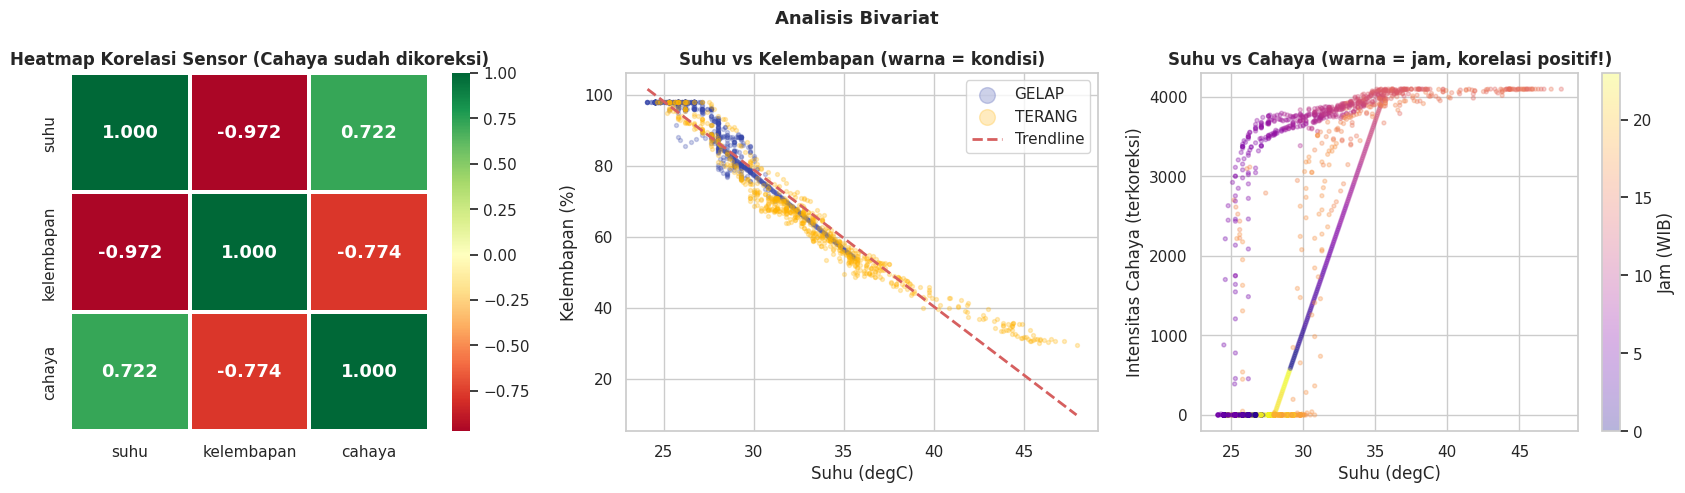


Interpretasi Korelasi (setelah koreksi LDR):
  Suhu <-> Kelembapan: r=-0.972 --> Negatif KUAT
                       Semakin panas -> udara makin kering
  Suhu <-> Cahaya    : r=0.722 --> Positif kuat
                       Semakin terang (matahari) -> semakin panas
  Kelembapan <-> Cahaya: r=-0.774 --> Negatif
                         Siang terang -> kelembapan rendah (matahari menguapkan air)


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Heatmap korelasi (setelah koreksi cahaya)
corr = df_feat[cols_sensor].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            ax=axes[0], square=True, linewidths=1.5,
            annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Heatmap Korelasi Sensor (Cahaya sudah dikoreksi)', fontweight='bold')

# 2. Scatter suhu vs kelembapan
cmap_k = {'TERANG': '#FFB300', 'GELAP': '#3949AB'}
for kondisi, grp in df_feat.groupby('kondisi'):
    axes[1].scatter(grp['suhu'], grp['kelembapan'],
                    label=kondisi, alpha=0.25, s=8, color=cmap_k.get(kondisi,'gray'))
coef = np.polyfit(df_feat['suhu'].dropna(), df_feat['kelembapan'].dropna(), 1)
x_line = np.linspace(df_feat['suhu'].min(), df_feat['suhu'].max(), 100)
axes[1].plot(x_line, np.polyval(coef, x_line), 'r--', lw=2, label='Trendline')
axes[1].set_xlabel('Suhu (degC)'); axes[1].set_ylabel('Kelembapan (%)')
axes[1].set_title('Suhu vs Kelembapan (warna = kondisi)', fontweight='bold')
axes[1].legend(markerscale=4)

# 3. Suhu vs cahaya (setelah koreksi)
sc = axes[2].scatter(df_feat['suhu'], df_feat['cahaya'],
                     c=df_feat['jam'], cmap='plasma', alpha=0.3, s=8)
plt.colorbar(sc, ax=axes[2], label='Jam (WIB)')
axes[2].set_xlabel('Suhu (degC)'); axes[2].set_ylabel('Intensitas Cahaya (terkoreksi)')
axes[2].set_title('Suhu vs Cahaya (warna = jam, korelasi positif!)', fontweight='bold')

plt.suptitle('Analisis Bivariat', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretasi Korelasi (setelah koreksi LDR):')
print(f'  Suhu <-> Kelembapan: r={corr.loc["suhu","kelembapan"]:.3f} --> Negatif KUAT')
print('                       Semakin panas -> udara makin kering')
print(f'  Suhu <-> Cahaya    : r={corr.loc["suhu","cahaya"]:.3f} --> Positif kuat')
print('                       Semakin terang (matahari) -> semakin panas')
print(f'  Kelembapan <-> Cahaya: r={corr.loc["kelembapan","cahaya"]:.3f} --> Negatif')
print('                         Siang terang -> kelembapan rendah (matahari menguapkan air)')

### 7.6 Multivariat (Heatmap Pola Suhu per Jam x Tanggal)

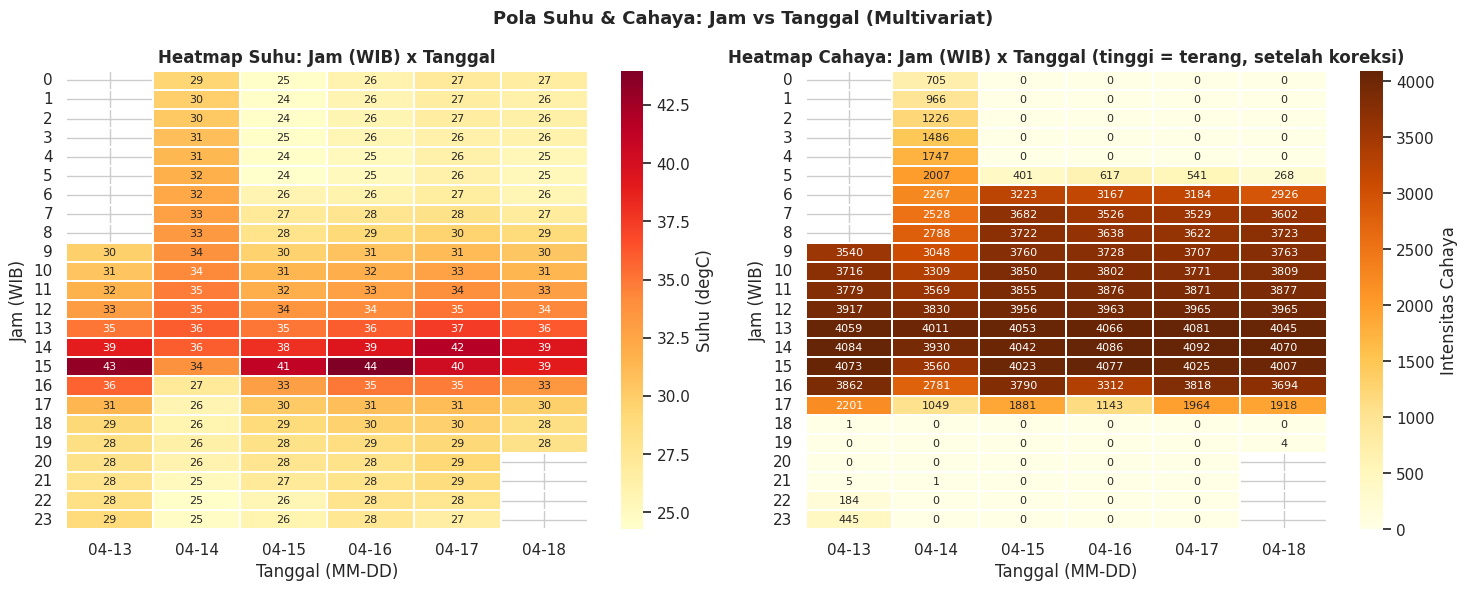


Insight:
  Baris jam 14-15: suhu paling merah (panas) di semua hari -- konsisten
  Baris jam 10-16: cahaya paling tinggi -- korelasi positif dengan suhu
  Baris jam 00-05: suhu biru (dingin) & cahaya nol (gelap total)
  13 Apr terlihat kosong di pagi hari karena sensor baru nyala jam 09:52


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
df_feat['tgl_str'] = df_feat['tanggal'].astype(str).str[5:]

pivot_suhu = df_feat.pivot_table(values='suhu', index='jam', columns='tgl_str', aggfunc='mean')
sns.heatmap(pivot_suhu, cmap='YlOrRd', ax=axes[0], linewidths=0.3, annot=True, fmt='.0f',
            cbar_kws={'label': 'Suhu (degC)'}, annot_kws={'size': 8})
axes[0].set_title('Heatmap Suhu: Jam (WIB) x Tanggal', fontweight='bold')
axes[0].set_xlabel('Tanggal (MM-DD)'); axes[0].set_ylabel('Jam (WIB)')

pivot_cahaya = df_feat.pivot_table(values='cahaya', index='jam', columns='tgl_str', aggfunc='mean')
sns.heatmap(pivot_cahaya, cmap='YlOrBr', ax=axes[1], linewidths=0.3, annot=True, fmt='.0f',
            cbar_kws={'label': 'Intensitas Cahaya'}, annot_kws={'size': 8})
axes[1].set_title('Heatmap Cahaya: Jam (WIB) x Tanggal (tinggi = terang, setelah koreksi)', fontweight='bold')
axes[1].set_xlabel('Tanggal (MM-DD)'); axes[1].set_ylabel('Jam (WIB)')

plt.suptitle('Pola Suhu & Cahaya: Jam vs Tanggal (Multivariat)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInsight:')
print('  Baris jam 14-15: suhu paling merah (panas) di semua hari -- konsisten')
print('  Baris jam 10-16: cahaya paling tinggi -- korelasi positif dengan suhu')
print('  Baris jam 00-05: suhu biru (dingin) & cahaya nol (gelap total)')
print('  13 Apr terlihat kosong di pagi hari karena sensor baru nyala jam 09:52')


### 7.7 Analisis Transisi Siang ke Malam

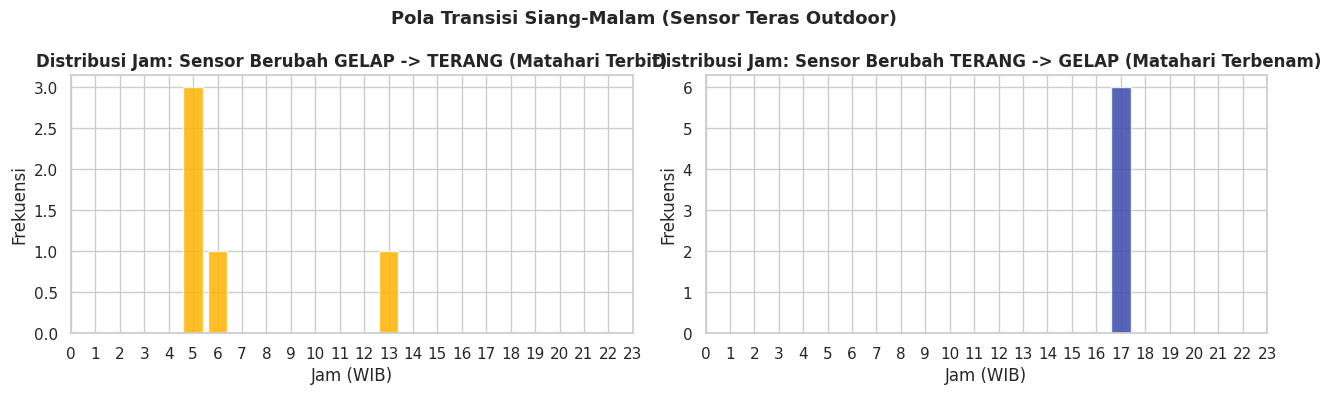


Insight:
  Matahari terbit  (sensor jadi TERANG): paling sering jam 05:00 WIB
  Matahari terbenam (sensor jadi GELAP): paling sering jam 17:00 WIB
  Ini konsisten dengan waktu terbit-terbenam di Semarang (~06:00 dan ~18:00 WIB)


In [35]:
# Jam berapa transisi TERANG->GELAP dan GELAP->TERANG terjadi?
df_feat['kondisi_num'] = (df_feat['kondisi'] == 'TERANG').astype(int)
transisi = df_feat['kondisi_num'].diff()

waktu_terbit = df_feat[transisi == 1]['jam'].value_counts().sort_index()
waktu_terbenam = df_feat[transisi == -1]['jam'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(waktu_terbit.index, waktu_terbit.values, color='#FFB300', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Jam: Sensor Berubah GELAP -> TERANG (Matahari Terbit)', fontweight='bold')
axes[0].set_xlabel('Jam (WIB)'); axes[0].set_ylabel('Frekuensi')
axes[0].set_xticks(range(0,24))

axes[1].bar(waktu_terbenam.index, waktu_terbenam.values, color='#3949AB', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Jam: Sensor Berubah TERANG -> GELAP (Matahari Terbenam)', fontweight='bold')
axes[1].set_xlabel('Jam (WIB)'); axes[1].set_ylabel('Frekuensi')
axes[1].set_xticks(range(0,24))

plt.suptitle('Pola Transisi Siang-Malam (Sensor Teras Outdoor)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInsight:')
terbit_jam = waktu_terbit.idxmax() if len(waktu_terbit) > 0 else 'N/A'
terbenam_jam = waktu_terbenam.idxmax() if len(waktu_terbenam) > 0 else 'N/A'
print(f'  Matahari terbit  (sensor jadi TERANG): paling sering jam {terbit_jam:02d}:00 WIB')
print(f'  Matahari terbenam (sensor jadi GELAP): paling sering jam {terbenam_jam:02d}:00 WIB')
print('  Ini konsisten dengan waktu terbit-terbenam di Semarang (~06:00 dan ~18:00 WIB)')


## 8. Deteksi Outlier

Dua metode digunakan untuk cross-validasi:
- **IQR Method**: nilai di luar [Q1 − 1.5×IQR, Q3 + 1.5×IQR]  
- **Z-Score**: |z| > 3

suhu        : IQR [16.25, 43.05] -> 44 outlier | Z-score: 35
kelembapan  : IQR [16.40, 145.20] -> 0 outlier | Z-score: 0
cahaya      : IQR [-5682.00, 9470.00] -> 0 outlier | Z-score: 0


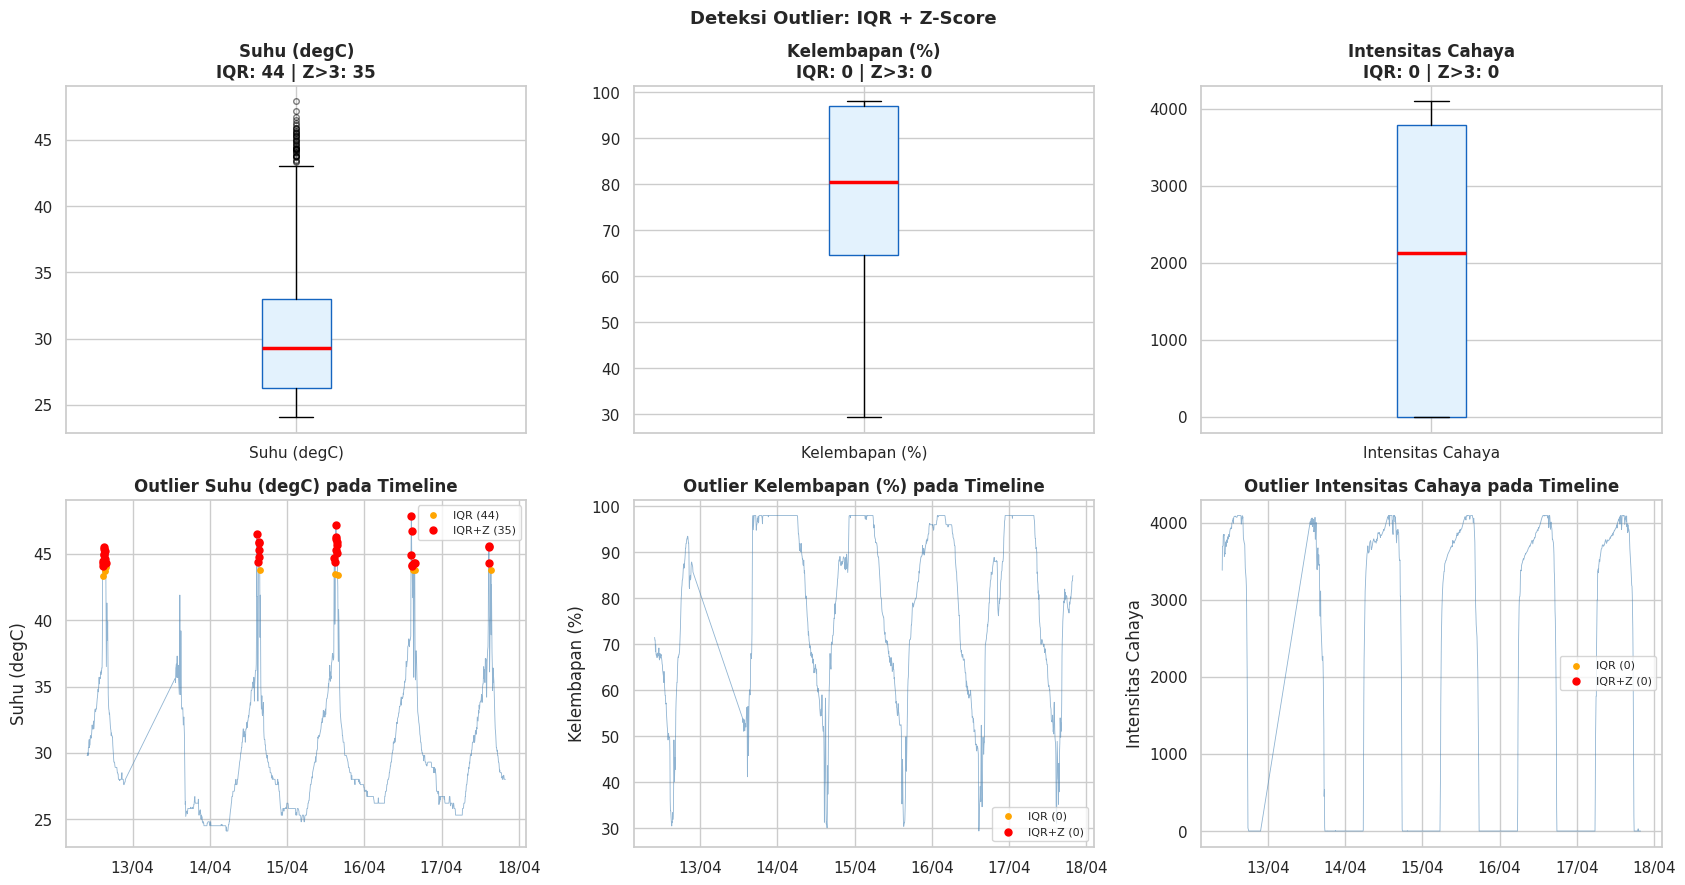


Catatan:
  Outlier suhu tinggi (~47 degC) terjadi jam 14-16 WIB -> paparan matahari langsung di teras
  Outlier kelembapan rendah (<30%) -> hari sangat panas dan kering
  Outlier cahaya -> transisi siang-malam atau awan tebal, perlu investigasi lebih lanjut
  TIDAK dihapus -- akan di-clip saat modeling untuk robustness


In [37]:
def detect_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return (series < lo) | (series > hi), lo, hi

def detect_zscore(series, threshold=3):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
labels_o = ['Suhu (degC)', 'Kelembapan (%)', 'Intensitas Cahaya']

for i, (col, label) in enumerate(zip(cols_sensor, labels_o)):
    is_iqr, lo, hi = detect_iqr(df_feat[col])
    is_z            = detect_zscore(df_feat[col])
    is_both         = is_iqr & is_z

    ax0 = axes[0, i]
    ax0.boxplot(df_feat[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD', color='#1565C0'),
                medianprops=dict(color='red', lw=2.5),
                flierprops=dict(marker='o', color='tomato', alpha=0.5, markersize=4))
    ax0.set_title(f'{label}\nIQR: {is_iqr.sum()} | Z>3: {is_z.sum()}', fontweight='bold')
    ax0.set_xticklabels([label])

    ax1 = axes[1, i]
    ax1.plot(df_feat.index, df_feat[col], color='steelblue', lw=0.6, alpha=0.6)
    ax1.scatter(df_feat[is_iqr].index, df_feat[is_iqr][col],
                color='orange', s=15, zorder=5, label=f'IQR ({is_iqr.sum()})')
    ax1.scatter(df_feat[is_both].index, df_feat[is_both][col],
                color='red', s=25, zorder=6, label=f'IQR+Z ({is_both.sum()})')
    ax1.set_title(f'Outlier {label} pada Timeline', fontweight='bold')
    ax1.set_ylabel(label)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax1.legend(fontsize=8)

    print(f'{col:12s}: IQR [{lo:.2f}, {hi:.2f}] -> {is_iqr.sum()} outlier | Z-score: {is_z.sum()}')

plt.suptitle('Deteksi Outlier: IQR + Z-Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCatatan:')
print('  Outlier suhu tinggi (~47 degC) terjadi jam 14-16 WIB -> paparan matahari langsung di teras')
print('  Outlier kelembapan rendah (<30%) -> hari sangat panas dan kering')
print('  Outlier cahaya -> transisi siang-malam atau awan tebal, perlu investigasi lebih lanjut')
print('  TIDAK dihapus -- akan di-clip saat modeling untuk robustness')